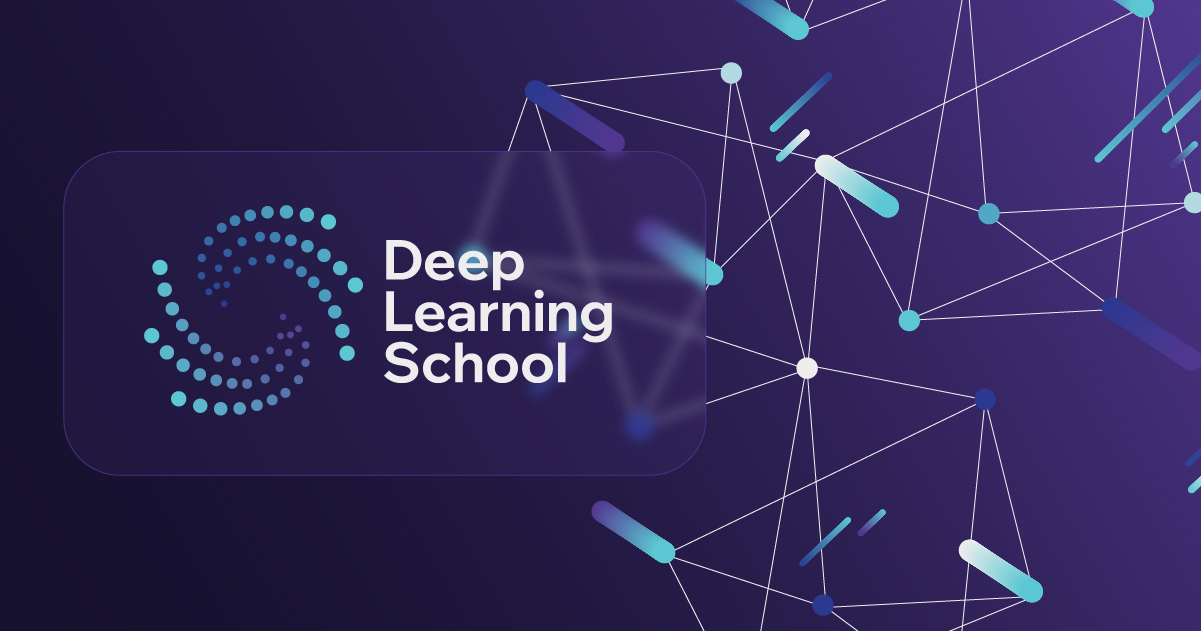


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [22]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import os
import pandas as pd
import skimage.io
from skimage.transform import resize
from torch.utils.data import DataLoader, TensorDataset

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [ ]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [ ]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Using Colab cache for faster access to the 'lfw-attributes' dataset.
Path to dataset files: /kaggle/input/lfw-attributes


In [ ]:
DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [ ]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [ ]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [ ]:
  # <тут Ваш код>
  train_idx, val_idx = train_test_split(
      np.arange(len(images)),
      test_size=0.2,
      random_state=42,
      stratify=None
  )

  train_images = images[train_idx]
  train_attrs = attrs.iloc[train_idx]
  val_images = images[val_idx]
  val_attrs = attrs.iloc[val_idx]

  print(f"Train size: {len(train_images)}, Val size: {len(val_images)}")

Train size: 10514, Val size: 2629


In [ ]:
train_attrs.head()

,Male,Asian,White,Black,Baby,Child,Youth,Middle Aged,Senior,Black Hair,...,Pale Skin,5 o' Clock Shadow,Strong Nose-Mouth Lines,Wearing Lipstick,Flushed Face,High Cheekbones,Brown Eyes,Wearing Earrings,Wearing Necktie,Wearing Necklace
10439,1.627359,-1.332487,0.891952,-1.652381,-1.990874,-1.212777,-0.699928,-0.258194,-0.414028,-1.370233,...,3.441252,1.614574,0.913775,-1.472451,-1.949881,-0.868596,1.022726,-0.956537,0.295897,-1.542998
9878,1.739172,-0.244157,0.337638,-2.544092,-2.490565,-2.027527,-0.734316,-0.374521,-0.288422,-1.107724,...,-1.060372,0.209459,0.550802,-1.728843,0.480825,0.738112,0.730442,-0.699853,0.736918,-1.108622
12613,-1.079295,-1.143018,1.083233,-1.8307,-2.349624,-0.896765,-0.967658,-0.350181,-0.091796,-2.106697,...,2.456819,-1.383696,1.21406,0.392216,-2.327813,0.512957,-0.720801,0.693671,-1.292678,0.284578
5758,-0.420605,-1.303524,1.236995,-1.864562,-1.523178,-0.656108,0.089447,0.062274,-1.057031,-0.834269,...,0.270975,-1.51291,0.668466,-0.172443,-3.632588,0.162344,-0.348943,-0.117881,-0.775081,0.189958
88,-0.975435,-0.746867,0.658828,-2.613938,-1.352,-2.053944,0.593879,-0.43186,-1.981534,0.077876,...,0.584507,-1.664275,0.844532,1.033722,-1.133336,0.875383,1.873177,0.130292,-0.534467,0.670804


In [ ]:
train_attrs.columns

Index(['Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth',
       'Middle Aged', 'Senior', 'Black Hair', 'Blond Hair', 'Brown Hair',
       'Bald', 'No Eyewear', 'Eyeglasses', 'Sunglasses', 'Mustache', 'Smiling',
       'Frowning', 'Chubby', 'Blurry', 'Harsh Lighting', 'Flash',
       'Soft Lighting', 'Outdoor', 'Curly Hair', 'Wavy Hair', 'Straight Hair',
       'Receding Hairline', 'Bangs', 'Sideburns', 'Fully Visible Forehead',
       'Partially Visible Forehead', 'Obstructed Forehead', 'Bushy Eyebrows',
       'Arched Eyebrows', 'Narrow Eyes', 'Eyes Open', 'Big Nose',
       'Pointy Nose', 'Big Lips', 'Mouth Closed', 'Mouth Slightly Open',
       'Mouth Wide Open', 'Teeth Not Visible', 'No Beard', 'Goatee',
       'Round Jaw', 'Double Chin', 'Wearing Hat', 'Oval Face', 'Square Face',
       'Round Face', 'Color Photo', 'Posed Photo', 'Attractive Man',
       'Attractive Woman', 'Indian', 'Gray Hair', 'Bags Under Eyes',
       'Heavy Makeup', 'Rosy Cheeks', 'Shiny Skin', 'Pa

In [ ]:
train_attrs['Smiling'].unique()

array([-1.21703619685, 0.695230494824, 1.24254281387, ..., 0.950315198624,
       -0.624230075025, -0.483131994946], dtype=object)

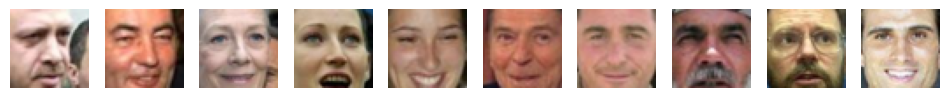

In [ ]:
num_examples = 10
plt.figure(figsize=(12, 6))
for i in range(num_examples):
    plt.subplot(1, num_examples, i+1)
    img = train_images[i]
    if img.max() > 1.0:
        img = img / 255.0
    if img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))
    plt.imshow(img)
    plt.axis('off')
plt.show()

In [ ]:
def to_tensor(images, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """Принимает numpy массив (N, H, W, C) с диапазоном 0..255, возвращает тензор (N, C, H, W) нормализованный."""
    images = images.astype(np.float32) / 255.0
    # Меняем оси: (N, H, W, C) -> (N, C, H, W)
    images = np.transpose(images, (0, 3, 1, 2))
    for i in range(3):
        images[:, i, :, :] = (images[:, i, :, :] - mean[i]) / std[i]
    return torch.tensor(images)

train_tensor = to_tensor(train_images)
val_tensor = to_tensor(val_images)

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



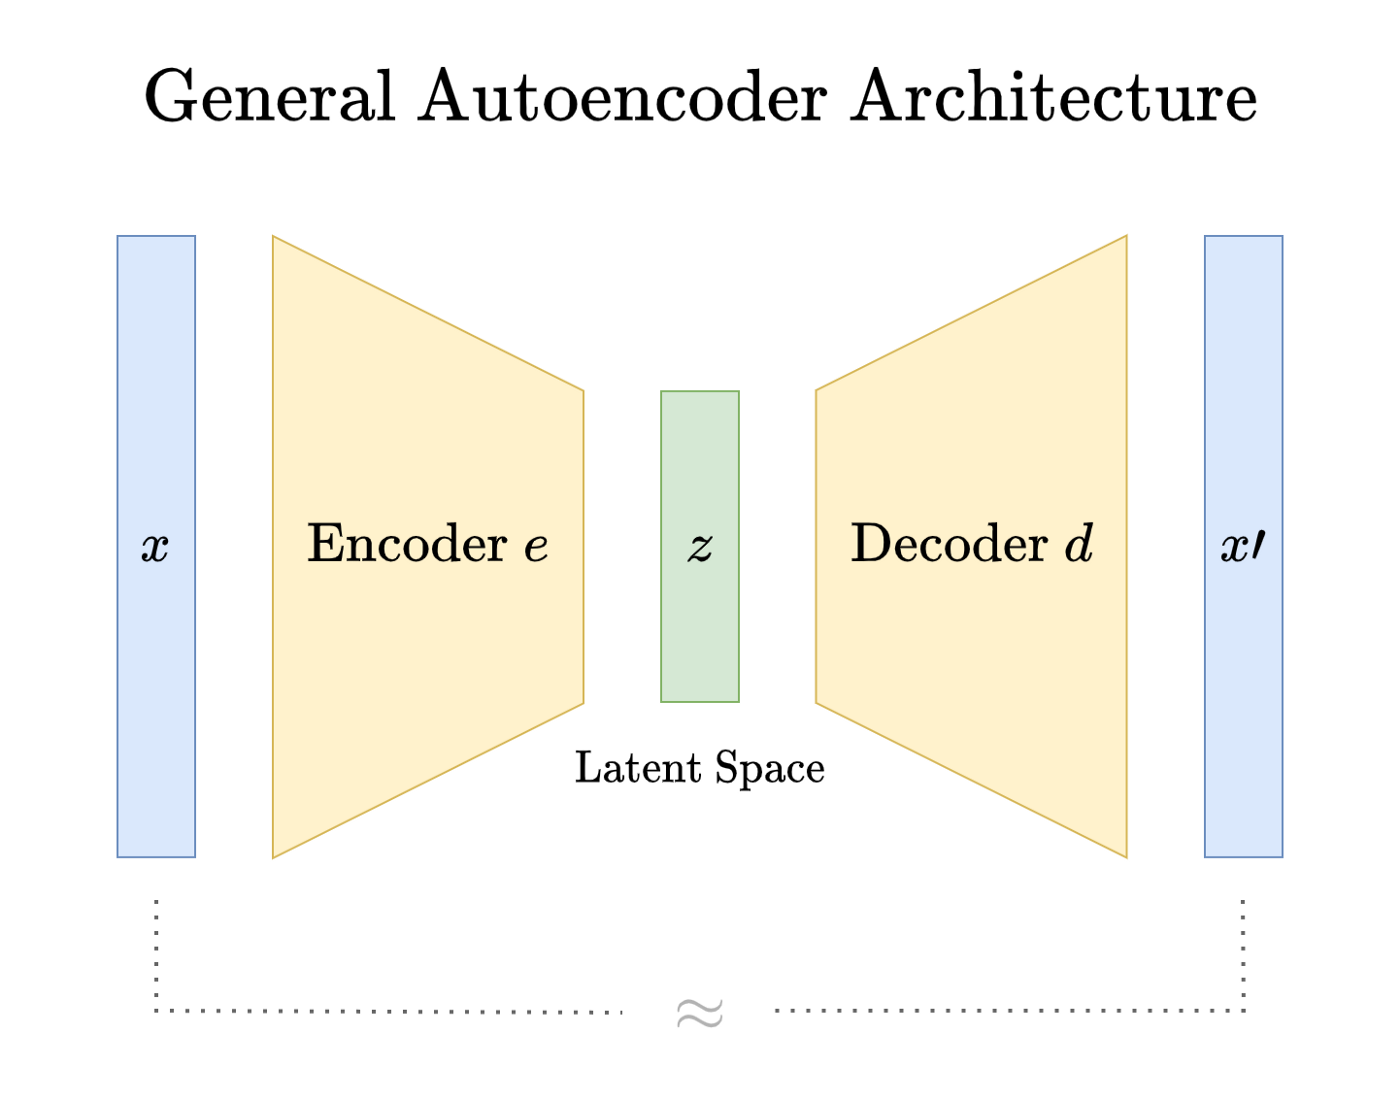

In [ ]:
dim_code = 128 # как базовый вариант


Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, input_channels=3):
        # <определите архитектуры encoder и decoder>
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, 3, 2, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(512*3*3, dim_code)
        )

        self.decoder = nn.Sequential(
            nn.Linear(dim_code, 512 * 3 * 3),
            nn.ReLU(),
            nn.Unflatten(1, (512, 3, 3)),
            nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, input_channels, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.Sigmoid()
        )
    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        # в качестве возвращаемых переменных -- латентное представление картинки (latent_code)
        # и полученная реконструкция изображения (reconstruction)

        return reconstruction, latent_code

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(train_tensor)
val_dataset = TensorDataset(val_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device, pbar=None):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        images = batch[0].to(device)

        optimizer.zero_grad()
        reconstructed, _ = model(images)
        loss = criterion(reconstructed, images)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size

        if pbar is not None:
            pbar.update(1)
            pbar.set_postfix({'loss': loss.item()})

    return total_loss / len(dataloader.dataset)

def validate(model, dataloader, criterion, device, pbar=None):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            reconstructed, _ = model(images)
            loss = criterion(reconstructed, images)
            batch_size = images.size(0)
            total_loss += loss.item() * batch_size

            if pbar is not None:
                pbar.update(1)
                pbar.set_postfix({'loss': loss.item()})

    return total_loss / len(dataloader.dataset)

In [ ]:
def train(model, num_epochs, dataloaders, optimizer, loss_func, device=None):

    model = model.to(device)
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, num_epochs + 1):
        # Прогресс-бар для тренировочных батчей
        with tqdm(total=len(dataloaders['train']), desc=f"Epoch {epoch}/{num_epochs} [Train]", unit="batch") as pbar_train:
            train_loss = train_one_epoch(model, dataloaders['train'], loss_func, optimizer, device, pbar=pbar_train)

        # Прогресс-бар для валидационных батчей (опционально, можно без pbar)
        with tqdm(total=len(dataloaders['val']), desc=f"Epoch {epoch}/{num_epochs} [Val]", unit="batch") as pbar_val:
            val_loss = validate(model, dataloaders['val'], loss_func, device, pbar=pbar_val)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f"Epoch {epoch:2d} Summary | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_autoencoder.pth")
            print("  -> saved best model")

    return history, best_val_loss

Epoch 1/30 [Val]: 100%|██████████| 83/83 [00:10<00:00,  7.97batch/s, loss=0.341]


Epoch  1 Summary | Train Loss: 0.440348 | Val Loss: 0.393091
  -> saved best model


Epoch 2/30 [Val]: 100%|██████████| 83/83 [00:11<00:00,  7.39batch/s, loss=0.322]


Epoch  2 Summary | Train Loss: 0.386784 | Val Loss: 0.377357
  -> saved best model


Epoch 3/30 [Val]: 100%|██████████| 83/83 [00:11<00:00,  7.24batch/s, loss=0.314]


...

Epoch 28 Summary | Train Loss: 0.348297 | Val Loss: 0.352296


Epoch 29/30 [Val]: 100%|██████████| 83/83 [00:10<00:00,  7.72batch/s, loss=0.297]


Epoch 29 Summary | Train Loss: 0.348105 | Val Loss: 0.352034
  -> saved best model


Epoch 30/30 [Val]: 100%|██████████| 83/83 [00:11<00:00,  7.30batch/s, loss=0.296]


Epoch 30 Summary | Train Loss: 0.347608 | Val Loss: 0.351871
  -> saved best model


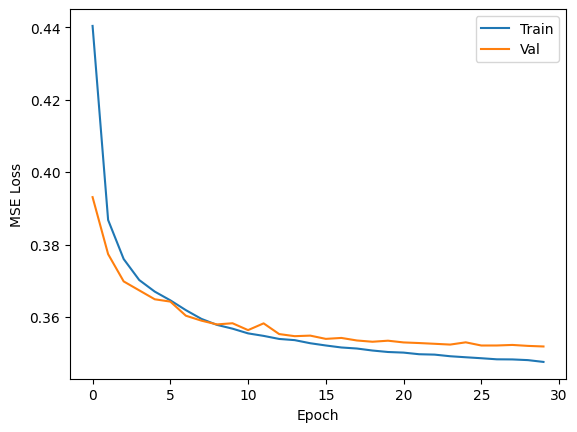

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

dataloaders = {
    'train': train_loader,
    'val': val_loader
}

history, best_val_loss = train(
    model=autoencoder,
    num_epochs=30,
    dataloaders=dataloaders,
    optimizer=optimizer,
    loss_func=criterion,
    device=device
)

import matplotlib.pyplot as plt
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

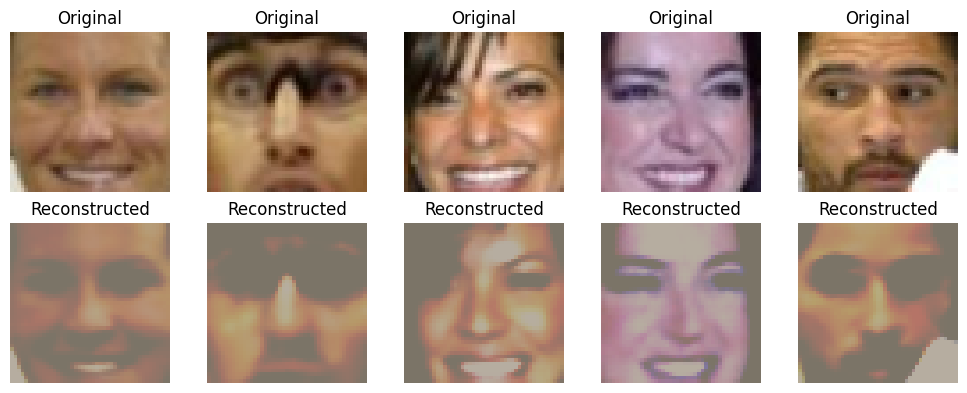

In [ ]:
autoencoder.eval()

with torch.no_grad():
    for batch in val_loader:
        images = batch[0].to(device)          # (B, 3, 45, 45)
        reconstructions, _ = autoencoder(images)
        break

images = images.cpu().numpy()
reconstructions = reconstructions.cpu().numpy()

mean = np.array([0.485, 0.456, 0.406]).reshape(1, -1, 1, 1)
std = np.array([0.229, 0.224, 0.225]).reshape(1, -1, 1, 1)
images = images * std + mean
reconstructions = reconstructions * std + mean
images = np.clip(images, 0, 1)
reconstructions = np.clip(reconstructions, 0, 1)

images = np.transpose(images, (0, 2, 3, 1))
reconstructions = np.transpose(reconstructions, (0, 2, 3, 1))

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    plt.imshow(reconstructions[i])
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

Что вы можете сказать про результат?

Безусловно, результат не идеальный - картинки сильно размыты, без мелких деталей, но в целом хотя бы что-то похожее на оригинал выводится

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [ ]:
autoencoder.eval()
all_latents = []

with torch.no_grad():
    for batch in val_loader:   # можно и train_loader
        images = batch[0].to(device)
        _, latent = autoencoder(images)   # latent - это код, который вы возвращаете
        all_latents.append(latent.cpu().numpy())

all_latents = np.concatenate(all_latents, axis=0)
print(f"Latents shape: {all_latents.shape}")

Latents shape: (2629, 128)


In [ ]:
mean_latent = all_latents.mean(axis=0)
std_latent = all_latents.std(axis=0)
print(f"Mean: {mean_latent[:5]}")
print(f"Std: {std_latent[:5]}")

Mean: [ 1.9687097  -0.5068318  -2.0999622  -0.15297729  4.307695  ]
Std: [10.555109  8.235342  9.317915  9.821877 11.869139]


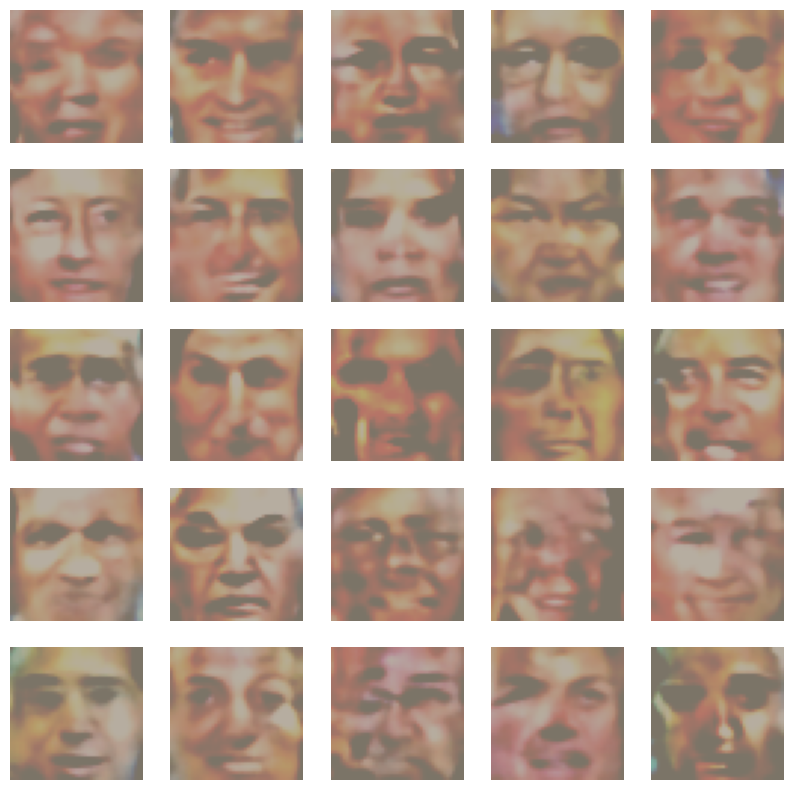

In [ ]:
# сгенерируем 25 рандомных векторов размера latent_space
z = np.random.randn(25, dim_code)
z = z * std_latent + mean_latent
output = autoencoder.decoder(torch.tensor(z, dtype=torch.float32).to(device))

output = output.detach().cpu().numpy()  # (25, 3, 45, 45)
mean = np.array([0.485, 0.456, 0.406]).reshape(1, -1, 1, 1)
std = np.array([0.229, 0.224, 0.225]).reshape(1, -1, 1, 1)
output = output * std + mean
output = np.clip(output, 0, 1)

output = np.transpose(output, (0, 2, 3, 1))

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(output[i])
    plt.axis('off')
plt.show()

жизнь при инсульте...
после добавления batch norm сильно ухудшилась генерация лиц.

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

Выяснили, что значения атрибутов нормализованы и не бинарны. делаем через неравенство

In [ ]:
smiling_mask = train_attrs['Smiling'] > 0
non_smiling_mask = train_attrs['Smiling'] < 0

print(f"Улыбающихся (Smiling > 0): {smiling_mask.sum()}")
print(f"Не улыбающихся (Smiling < 0): {non_smiling_mask.sum()}")

n_samples = 15
smiling_idx = np.where(smiling_mask)[0][:n_samples]
non_smiling_idx = np.where(non_smiling_mask)[0][:n_samples]

smiling_images = train_images[smiling_idx]
non_smiling_images = train_images[non_smiling_idx]

def get_latents(imgs):
    autoencoder.eval()
    latents = []
    for img in imgs:
        img_tensor = to_tensor(img[np.newaxis, ...]).to(device)  # (1,3,45,45)
        with torch.no_grad():
            _, z = autoencoder(img_tensor)
        latents.append(z.cpu().numpy().squeeze())
    return np.array(latents)

smiling_latents = get_latents(smiling_images)
non_smiling_latents = get_latents(non_smiling_images)

mean_smile = smiling_latents.mean(axis=0)
mean_no_smile = non_smiling_latents.mean(axis=0)
smile_vector = mean_smile - mean_no_smile

print("Вектор улыбки вычислен. Норма:", np.linalg.norm(smile_vector))

Улыбающихся (Smiling > 0): 4339
Не улыбающихся (Smiling < 0): 6175
Вектор улыбки вычислен. Норма: 48.71614


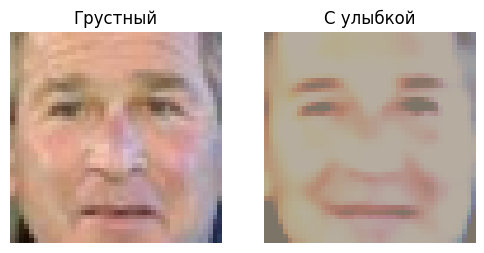

In [ ]:
test_idx = non_smiling_idx[3]
orig_img = train_images[test_idx]  # (45,45,3)
orig_tensor = to_tensor(orig_img[np.newaxis, ...]).to(device)

with torch.no_grad():
    _, z_orig = autoencoder(orig_tensor)
    z_new = z_orig + torch.tensor(smile_vector, device=device).reshape(1, -1)
    new_img = autoencoder.decoder(z_new).cpu().numpy().squeeze()  # (3,45,45)

# Денормализация для показа
mean_img = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
std_img = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)
new_img = new_img * std_img + mean_img
new_img = np.clip(new_img, 0, 1).transpose(1,2,0)

orig_viz = orig_img / 255.0

# Показываем
plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.imshow(orig_viz); plt.title("Грустный"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(new_img); plt.title("С улыбкой"); plt.axis('off')
plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [2]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.13MB/s]


## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 14 -> 7
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # 7 -> 7 (no size change)
            nn.ReLU()
        )
        # Flatten: 128 * 7 * 7 = 6272
        self.fc_mu = nn.Linear(6272, latent_dim)
        self.fc_logsigma = nn.Linear(6272, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim, 6272)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 14 -> 28
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),  # 28 -> 28
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)
        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 128, 7, 7)
        return self.decoder(h)

    def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        recon = self.decode(z)
        return mu, logsigma, recon

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [ ]:
def KL_divergence(mu, logsigma):
    """
    KL divergence between q(z|x) and p(z) ~ N(0, I)
    logsigma is log(sigma^2) (log variance)
    """
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp(), dim=1)
    return loss.mean()

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = F.binary_cross_entropy(reconstruction, x, reduction='sum')
    return loss / x.size(0)

def loss_vae(x, mu, logsigma, reconstruction):
    kl = KL_divergence(mu, logsigma)
    recon = log_likelihood(x, reconstruction)
    return kl + recon

И обучим модель:

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = loss_vae

autoencoder = VAE().to(device)

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device, pbar=None):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        images = batch[0].to(device)

        optimizer.zero_grad()
        mu, logsigma, reconstruction = model(images)
        loss = criterion(images, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size

        if pbar is not None:
            pbar.update(1)
            pbar.set_postfix({'loss': loss.item()})

    return total_loss / len(dataloader.dataset)

def validate(model, dataloader, criterion, device, pbar=None):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            mu, logsigma, reconstruction = model(images)
            loss = criterion(images, mu, logsigma, reconstruction)
            batch_size = images.size(0)
            total_loss += loss.item() * batch_size

            if pbar is not None:
                pbar.update(1)
                pbar.set_postfix({'loss': loss.item()})

    return total_loss / len(dataloader.dataset)

def train(model, num_epochs, dataloaders, optimizer, loss_func, device=None):
    model = model.to(device)
    best_val_loss = float('inf')

    for epoch in range(1, num_epochs + 1):
        with tqdm(total=len(dataloaders['train']), desc=f"Epoch {epoch}/{num_epochs} [Train]", unit="batch") as pbar_train:
            train_loss = train_one_epoch(model, dataloaders['train'], loss_func, optimizer, device, pbar=pbar_train)

        with tqdm(total=len(dataloaders['val']), desc=f"Epoch {epoch}/{num_epochs} [Val]", unit="batch") as pbar_val:
            val_loss = validate(model, dataloaders['val'], loss_func, device, pbar=pbar_val)

        print(f"Epoch {epoch:2d} Summary | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_vae.pth")
            print("  -> saved best VAE model")

    return best_val_loss

In [ ]:
dataloaders = {
    'train': train_loader,
    'val': test_loader
}

best_loss = train(autoencoder, num_epochs=20, dataloaders=dataloaders,
                  optimizer=optimizer, loss_func=criterion, device=device)

Epoch 1/20 [Val]: 100%|██████████| 313/313 [00:14<00:00, 21.86batch/s, loss=89.6]


Epoch  1 Summary | Train Loss: 127.426117 | Val Loss: 96.115910
  -> saved best VAE model


Epoch 2/20 [Val]: 100%|██████████| 313/313 [00:13<00:00, 22.77batch/s, loss=87.9]


Epoch  2 Summary | Train Loss: 104.194551 | Val Loss: 93.718934
  -> saved best VAE model


Epoch 3/20 [Val]: 100%|██████████| 313/313 [00:14<00:00, 21.92batch/s, loss=87.8]


...

Epoch 10 Summary | Train Loss: 97.671177 | Val Loss: 88.798816
  -> saved best VAE model


Epoch 11/20 [Val]: 100%|██████████| 313/313 [00:15<00:00, 19.90batch/s, loss=84.2]


Epoch 11 Summary | Train Loss: 97.351413 | Val Loss: 88.997431


Epoch 12/20 [Train]:   5%|▍         | 91/1875 [00:15<05:04,  5.85batch/s, loss=92.8]


KeyboardInterrupt: 

In [ ]:
autoencoder.load_state_dict(torch.load("best_vae.pth"))
autoencoder.to(device)
autoencoder.eval()
print("Best VAE model loaded.")

Best VAE model loaded.


Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

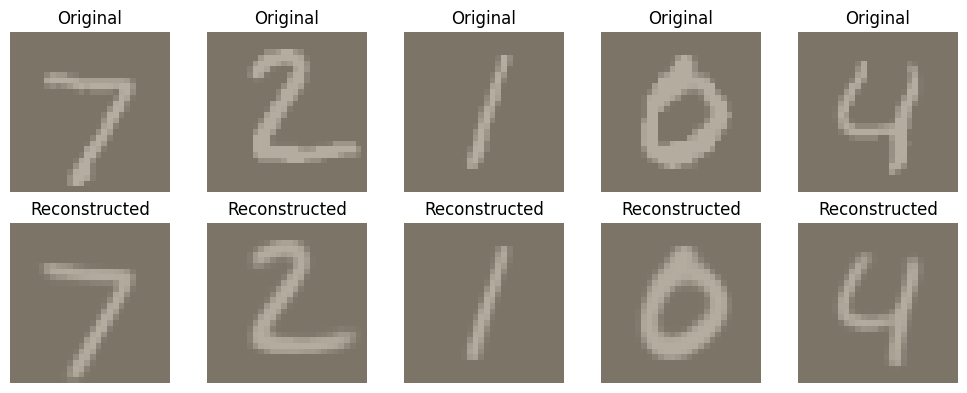

In [ ]:
autoencoder.eval()

with torch.no_grad():
    for batch in test_loader:
        images, _ = batch
        images = images.to(device)
        mu, logsigma, reconstructions = autoencoder(images)
        break
images = images.cpu().numpy()
reconstructions = reconstructions.cpu().numpy()

if 'mean' in locals() and 'std' in locals():
    images = images * std + mean
    reconstructions = reconstructions * std + mean

images = np.clip(images, 0, 1)
reconstructions = np.clip(reconstructions, 0, 1)

images = np.transpose(images, (0, 2, 3, 1))
reconstructions = np.transpose(reconstructions, (0, 2, 3, 1))

X = 5
plt.figure(figsize=(10, 4))
for i in range(X):
    plt.subplot(2, X, i+1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, X, i+X+1)
    plt.imshow(reconstructions[i])
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

(10000, 20)


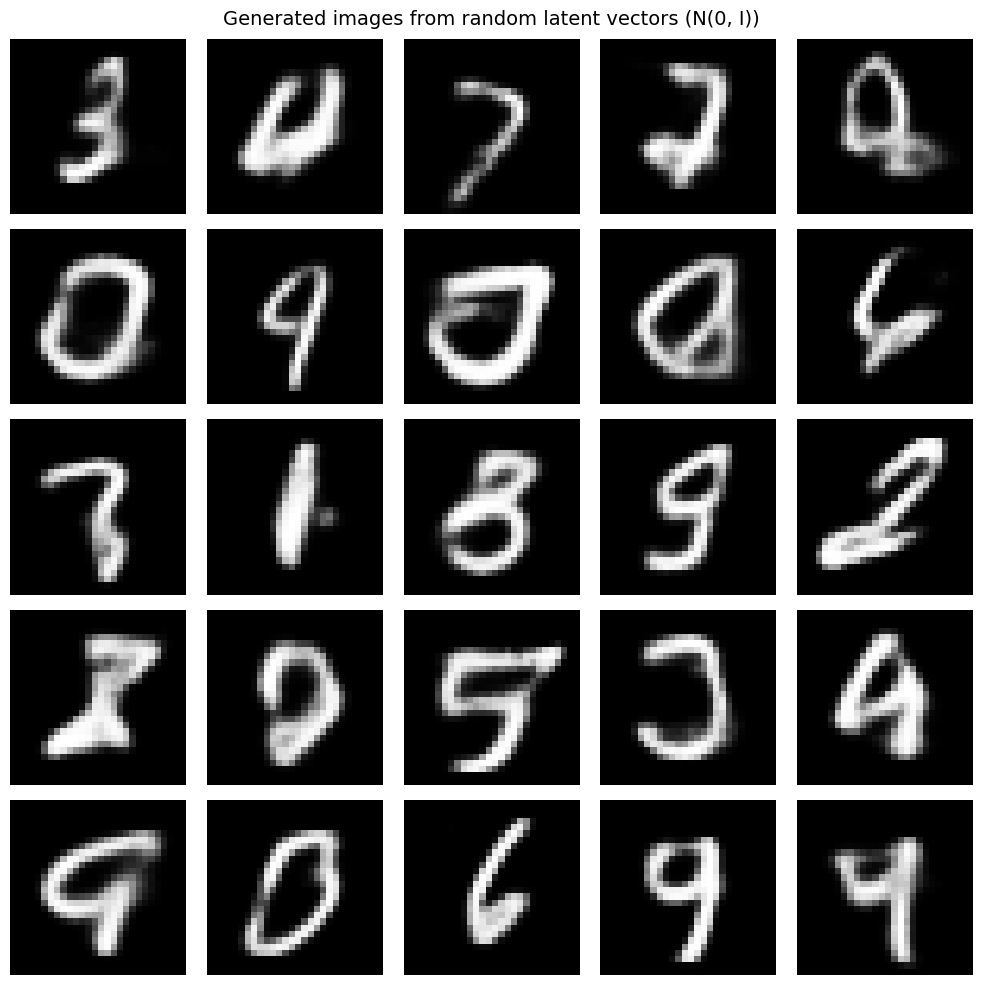

In [ ]:
autoencoder.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu, _, _ = autoencoder(images)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_mu = np.concatenate(all_mu, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
print(all_mu.shape)

num_images = 25
latent_dim = autoencoder.latent_dim

z = np.random.randn(num_images, latent_dim)

z_tensor = torch.tensor(z, dtype=torch.float32).to(device)

with torch.no_grad():
    generated = autoencoder.decode(z_tensor)

generated = generated.cpu().numpy()

if generated.shape[1] == 1:
    generated = generated.squeeze(axis=1)
    cmap = 'gray'
else:
    generated = np.transpose(generated, (0, 2, 3, 1))
    cmap = None

plt.figure(figsize=(10, 10))
for i in range(num_images):
    plt.subplot(5, 5, i+1)
    plt.imshow(generated[i], cmap=cmap)
    plt.axis('off')
plt.suptitle("Generated images from random latent vectors (N(0, I))", fontsize=14)
plt.tight_layout()
plt.show()

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

Shape of latent vectors: (10000, 20)
Shape of labels: (10000,)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


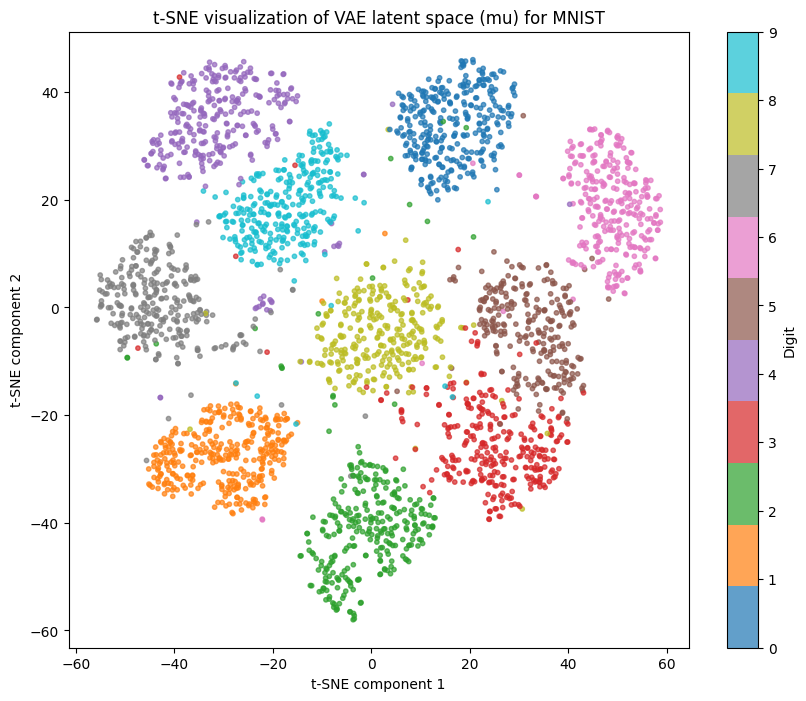

In [ ]:
from sklearn.manifold import TSNE
autoencoder.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu, _, _ = autoencoder(images)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_mu = np.concatenate(all_mu, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Shape of latent vectors: {all_mu.shape}")
print(f"Shape of labels: {all_labels.shape}")



# Для ускорения берем подвыборку 3000 точек
n_samples = 3000
if len(all_mu) > n_samples:
    indices = np.random.choice(len(all_mu), n_samples, replace=False)
    mu_subset = all_mu[indices]
    labels_subset = all_labels[indices]
else:
    mu_subset = all_mu
    labels_subset = all_labels

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
mu_2d = tsne.fit_transform(mu_subset)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(mu_2d[:, 0], mu_2d[:, 1], c=labels_subset, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, ticks=range(10), label='Digit')
plt.title("t-SNE visualization of VAE latent space (mu) for MNIST")
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.show()

Что вы думаете о виде латентного представления?


классы довольно четко разделены. при этом похожие цифры (7, 1) и (0, 6,8,9) находятся ближе друг к другу чем непохожие.
также латентное представление по форме напоминает круг (за это отвечает KL divergence в лоссе, если я правильно поняла), но есть расстояние между классами (за это отвечает часть лосса reconstruction)

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [4]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=20, num_classes=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.encoder = nn.Sequential(
            nn.Conv2d(1 + num_classes, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()                                                          # 64*7*7 = 3136
        )
        self.fc_mu = nn.Linear(3136, latent_dim)
        self.fc_logsigma = nn.Linear(3136, latent_dim)

        self.decoder_fc = nn.Linear(latent_dim + num_classes, 3136)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def encode(self, x, class_num):
        batch_size = x.size(0)
        one_hot = torch.zeros(batch_size, self.num_classes, device=x.device)
        one_hot.scatter_(1, class_num.view(-1, 1), 1)
        one_hot = one_hot[:, :, None, None]
        one_hot = one_hot.expand(-1, -1, x.size(2), x.size(3))
        x_cond = torch.cat([x, one_hot], dim=1)
        h = self.encoder(x_cond)
        mu = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)
        return mu, logsigma, class_num

    def gaussian_sampler(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z, class_num):
        batch_size = z.size(0)
        one_hot = torch.zeros(batch_size, self.num_classes, device=z.device)
        one_hot.scatter_(1, class_num.view(-1, 1), 1)
        z_cond = torch.cat([z, one_hot], dim=1)
        h = self.decoder_fc(z_cond)
        recon = self.decoder(h)
        return recon

    def forward(self, x, class_num):
        mu, logsigma, _ = self.encode(x, class_num)
        z = self.gaussian_sampler(mu, logsigma)
        recon = self.decode(z, class_num)
        return mu, logsigma, recon


In [5]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

def loss_vae(recon, x, mu, logvar, beta=1.0):
    recon_loss = F.binary_cross_entropy(recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

def train_one_epoch(model, dataloader, loss_func, optimizer, device, pbar=None):
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    num_batches = 0

    for batch_idx, (data, target) in enumerate(dataloader):
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        mu, logvar, recon = model(data, target)
        loss, recon_loss, kl_loss = loss_func(recon, data, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()
        num_batches += 1

        if pbar is not None:
            pbar.update(1)
            pbar.set_postfix({'loss': loss.item()})

    n_samples = len(dataloader.dataset)
    avg_total = total_loss / n_samples
    avg_recon = total_recon / n_samples
    avg_kl = total_kl / n_samples
    return avg_total, avg_recon, avg_kl

def validate(model, dataloader, loss_func, device, pbar=None):
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    n_samples = len(dataloader.dataset)

    with torch.no_grad():
        for data, target in dataloader:
            data = data.to(device)
            target = target.to(device)
            mu, logvar, recon = model(data, target)
            loss, recon_loss, kl_loss = loss_func(recon, data, mu, logvar)
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            if pbar is not None:
                pbar.update(1)
                pbar.set_postfix({'loss': loss.item()})

    return (total_loss / n_samples,
            total_recon / n_samples,
            total_kl / n_samples)

def train(model, num_epochs, dataloaders, optimizer, loss_func, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, num_epochs + 1):
        with tqdm(total=len(dataloaders['train']),
                  desc=f"Epoch {epoch}/{num_epochs} [Train]",
                  unit="batch") as pbar_train:
            train_loss, train_recon, train_kl = train_one_epoch(
                model, dataloaders['train'], loss_func, optimizer, device, pbar=pbar_train
            )

        with tqdm(total=len(dataloaders['val']),
                  desc=f"Epoch {epoch}/{num_epochs} [Val]",
                  unit="batch") as pbar_val:
            val_loss, val_recon, val_kl = validate(
                model, dataloaders['val'], loss_func, device, pbar=pbar_val
            )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f"Epoch {epoch:2d} Summary | "
              f"Train Loss: {train_loss:.4f} (recon: {train_recon:.1f}, kl: {train_kl:.1f}) | "
              f"Val Loss: {val_loss:.4f} (recon: {val_recon:.1f}, kl: {val_kl:.1f})")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_cvae.pth")
            print("  -> saved best CVAE model")

    return best_val_loss, history

In [8]:
dataloaders = {'train': train_loader, 'val': test_loader}

latent_dim = 20
model = CVAE(latent_dim=latent_dim, num_classes=10)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_loss, hist = train(
    model=model,
    num_epochs=20,
    dataloaders=dataloaders,
    optimizer=optimizer,
    loss_func=loss_vae,
    device=device
)

Epoch 1/20 [Val]: 100%|██████████| 313/313 [00:05<00:00, 59.05batch/s, loss=1.48e+3]


Epoch  1 Summary | Train Loss: 131.0824 (recon: 109.0, kl: 22.1) | Val Loss: 100.4124 (recon: 77.3, kl: 23.1)
  -> saved best CVAE model


Epoch 2/20 [Val]: 100%|██████████| 313/313 [00:05<00:00, 53.54batch/s, loss=1.43e+3]


Epoch  2 Summary | Train Loss: 107.0336 (recon: 84.3, kl: 22.8) | Val Loss: 95.8700 (recon: 72.7, kl: 23.2)
  -> saved best CVAE model


Epoch 3/20 [Val]: 100%|██████████| 313/313 [00:06<00:00, 49.90batch/s, loss=1.37e+3]


...

Epoch 18 Summary | Train Loss: 96.5601 (recon: 75.1, kl: 21.4) | Val Loss: 88.3649 (recon: 66.9, kl: 21.5)


Epoch 19/20 [Val]: 100%|██████████| 313/313 [00:06<00:00, 51.62batch/s, loss=1.32e+3]


Epoch 19 Summary | Train Loss: 96.4205 (recon: 75.0, kl: 21.4) | Val Loss: 88.3908 (recon: 66.5, kl: 21.8)


Epoch 20/20 [Val]: 100%|██████████| 313/313 [00:06<00:00, 50.58batch/s, loss=1.32e+3]

Epoch 20 Summary | Train Loss: 96.2442 (recon: 74.9, kl: 21.3) | Val Loss: 87.8755 (recon: 66.9, kl: 21.0)
  -> saved best CVAE model


### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

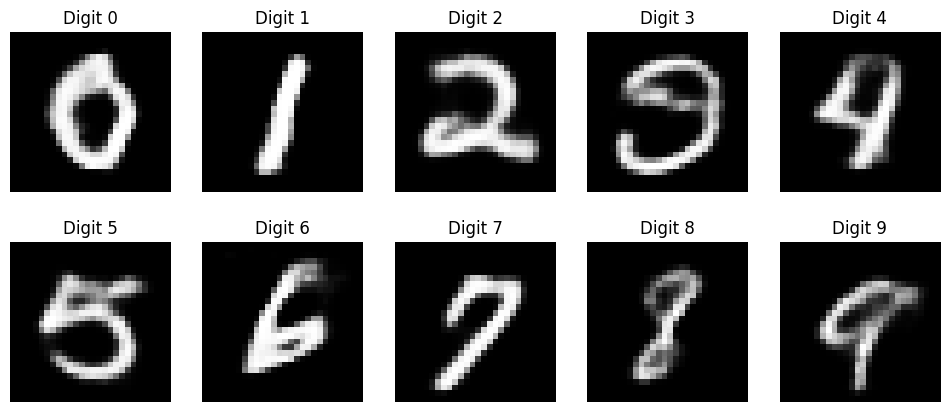

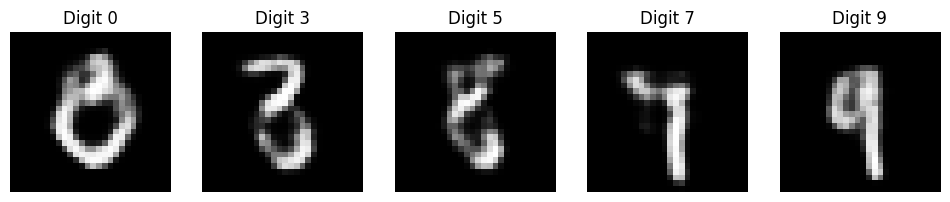

In [17]:
model.load_state_dict(torch.load("best_cvae.pth"))
model.eval()

plt.figure(figsize=(12,5))
for digit in range(10):
    z = torch.randn(1, latent_dim).to(device)
    class_tensor = torch.tensor([digit]).to(device)
    with torch.no_grad():
        img = model.decode(z, class_tensor).cpu().squeeze().numpy()
    plt.subplot(2,5,digit+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Digit {digit}')
    plt.axis('off')
plt.show()

z_fixed = torch.randn(1, latent_dim).to(device)
digits = [0, 3, 5, 7, 9]

plt.figure(figsize=(12,3))
for i, digit in enumerate(digits):
    class_tensor = torch.tensor([digit]).to(device)
    with torch.no_grad():
        img = model.decode(z_fixed, class_tensor).cpu().squeeze().numpy()
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Digit {digit}')
    plt.axis('off')
plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


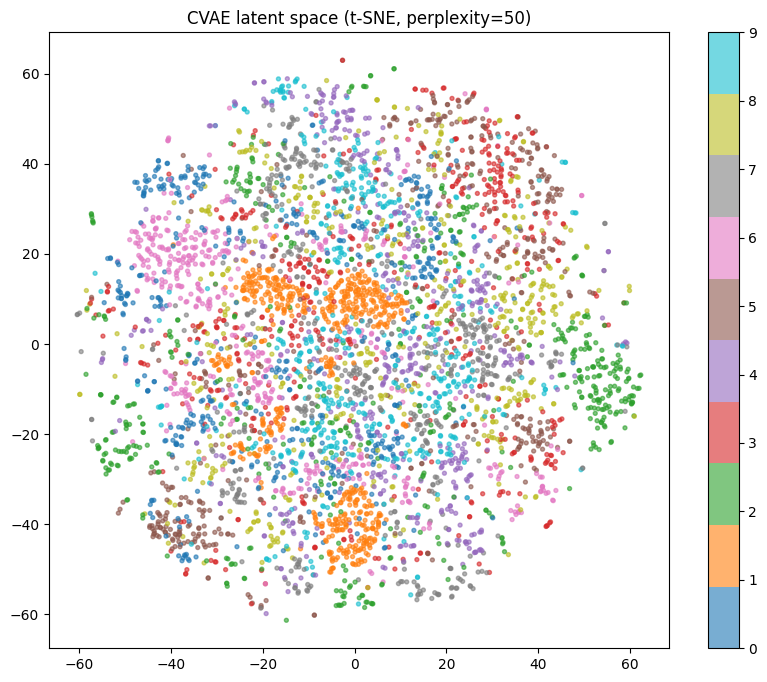

In [19]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Сбор mu для CVAE (убедитесь, что вызывается encode с метками)
mus_cvae = []
labels = []
model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        images, targets = images.to(device), targets.to(device)
        mu, _, _ = model.encode(images, targets)
        mus_cvae.append(mu.cpu().numpy())
        labels.append(targets.cpu().numpy())
mus_cvae = np.concatenate(mus_cvae, axis=0)
labels = np.concatenate(labels, axis=0)

n_samples = 5000
idx = np.random.choice(len(mus_cvae), n_samples, replace=False)
mus_sample = mus_cvae[idx]
labels_sample = labels[idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_iter=1500)
mus_2d = tsne.fit_transform(mus_sample)

plt.figure(figsize=(10,8))
sc = plt.scatter(mus_2d[:,0], mus_2d[:,1], c=labels_sample, cmap='tab10', s=8, alpha=0.6)
plt.colorbar(sc, ticks=range(10))
plt.title('CVAE latent space (t-SNE, perplexity=50)')
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

Интересное наблюдение, что согласно теории картина должна быть противоположной - облако точек в VAE и четкие кластеры в CVAE, поскольку он использует метки. однако что имеем  


# BONUS 1: Denoising (2 балла)



У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [23]:
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")

DATASET_PATH = "/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):
    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])
    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})
    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs, photo_ids, on=('person', 'imagenum'))
    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"
    images = df['photo_path'].apply(imageio.imread)\
                              .apply(lambda img: img[dy:-dy, dx:-dx])\
                              .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])))
    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"], axis=1)
    return images, attrs

images, attrs = fetch_dataset()

train_idx, val_idx = train_test_split(
    np.arange(len(images)),
    test_size=0.2,
    random_state=42,
    stratify=None
)
train_images_clean = images[train_idx]
val_images_clean   = images[val_idx]

noise_factor = 0.5

train_images_noisy = train_images_clean.astype(np.float32) + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=train_images_clean.shape)
val_images_noisy   = val_images_clean.astype(np.float32)   + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=val_images_clean.shape)

train_images_noisy = np.clip(train_images_noisy, 0, 255).astype(np.uint8)
val_images_noisy   = np.clip(val_images_noisy, 0, 255).astype(np.uint8)

def to_tensor(images):
    images = images.astype(np.float32) / 255.0
    images = np.transpose(images, (0, 3, 1, 2))
    return torch.tensor(images)

train_clean_t = to_tensor(train_images_clean)
val_clean_t   = to_tensor(val_images_clean)
train_noisy_t = to_tensor(train_images_noisy)
val_noisy_t   = to_tensor(val_images_noisy)

# DataLoader на вход подаём шум, на выходе чистый
train_dataset = TensorDataset(train_noisy_t, train_clean_t)
val_dataset   = TensorDataset(val_noisy_t, val_clean_t)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Using Colab cache for faster access to the 'lfw-attributes' dataset.


In [20]:
class DenoiseAE(nn.Module):
    def __init__(self, latent_dim=128, input_channels=3):
        super().__init__()
        # Энкодер: 45x45 -> 3x3
        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, 2, 1),   # 45->23
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),              # 23->12
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, 2, 1),             # 12->6
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, 2, 1),            # 6->3
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256*3*3, latent_dim)
        )
        # Декодер
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256*3*3),
            nn.ReLU(),
            nn.Unflatten(1, (256, 3, 3)),
            nn.ConvTranspose2d(256, 128, 3, 2, 1, output_padding=1),  # 3->6
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1),   # 6->12
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=0),    # 12->23
            nn.ReLU(),
            nn.ConvTranspose2d(32, input_channels, 3, 2, 1, output_padding=0), # 23->45
            nn.Sigmoid()
        )
    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoiseAE(latent_dim=128).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20
best_val_loss = float('inf')

for epoch in range(1, num_epochs+1):
    model.train()
    train_loss = 0.0
    for noisy, clean in train_loader:
        noisy, clean = noisy.to(device), clean.to(device)
        optimizer.zero_grad()
        recon, _ = model(noisy)
        loss = criterion(recon, clean)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * noisy.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for noisy, clean in val_loader:
            noisy, clean = noisy.to(device), clean.to(device)
            recon, _ = model(noisy)
            loss = criterion(recon, clean)
            val_loss += loss.item() * noisy.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch:2d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_denoiser.pth")
        print(" -> model saved")

Epoch  1 | Train MSE: 0.027336 | Val MSE: 0.013797
 -> model saved
Epoch  2 | Train MSE: 0.010244 | Val MSE: 0.008583
 -> model saved
Epoch  3 | Train MSE: 0.007646 | Val MSE: 0.007039
 -> model saved
Epoch  4 | Train MSE: 0.006507 | Val MSE: 0.006272
 -> model saved
Epoch  5 | Train MSE: 0.005753 | Val MSE: 0.005638
 -> model saved
Epoch  6 | Train MSE: 0.005117 | Val MSE: 0.004958
 -> model saved
Epoch  7 | Train MSE: 0.004715 | Val MSE: 0.004901
 -> model saved
Epoch  8 | Train MSE: 0.004393 | Val MSE: 0.004383
 -> model saved
Epoch  9 | Train MSE: 0.004139 | Val MSE: 0.004175
 -> model saved
Epoch 10 | Train MSE: 0.003899 | Val MSE: 0.003922
 -> model saved
Epoch 11 | Train MSE: 0.003743 | Val MSE: 0.003748
 -> model saved
Epoch 12 | Train MSE: 0.003573 | Val MSE: 0.003641
 -> model saved
Epoch 13 | Train MSE: 0.003439 | Val MSE: 0.003558
 -> model saved
Epoch 14 | Train MSE: 0.003322 | Val MSE: 0.003603
Epoch 15 | Train MSE: 0.003224 | Val MSE: 0.003315
 -> model saved
Epoch 16 | 

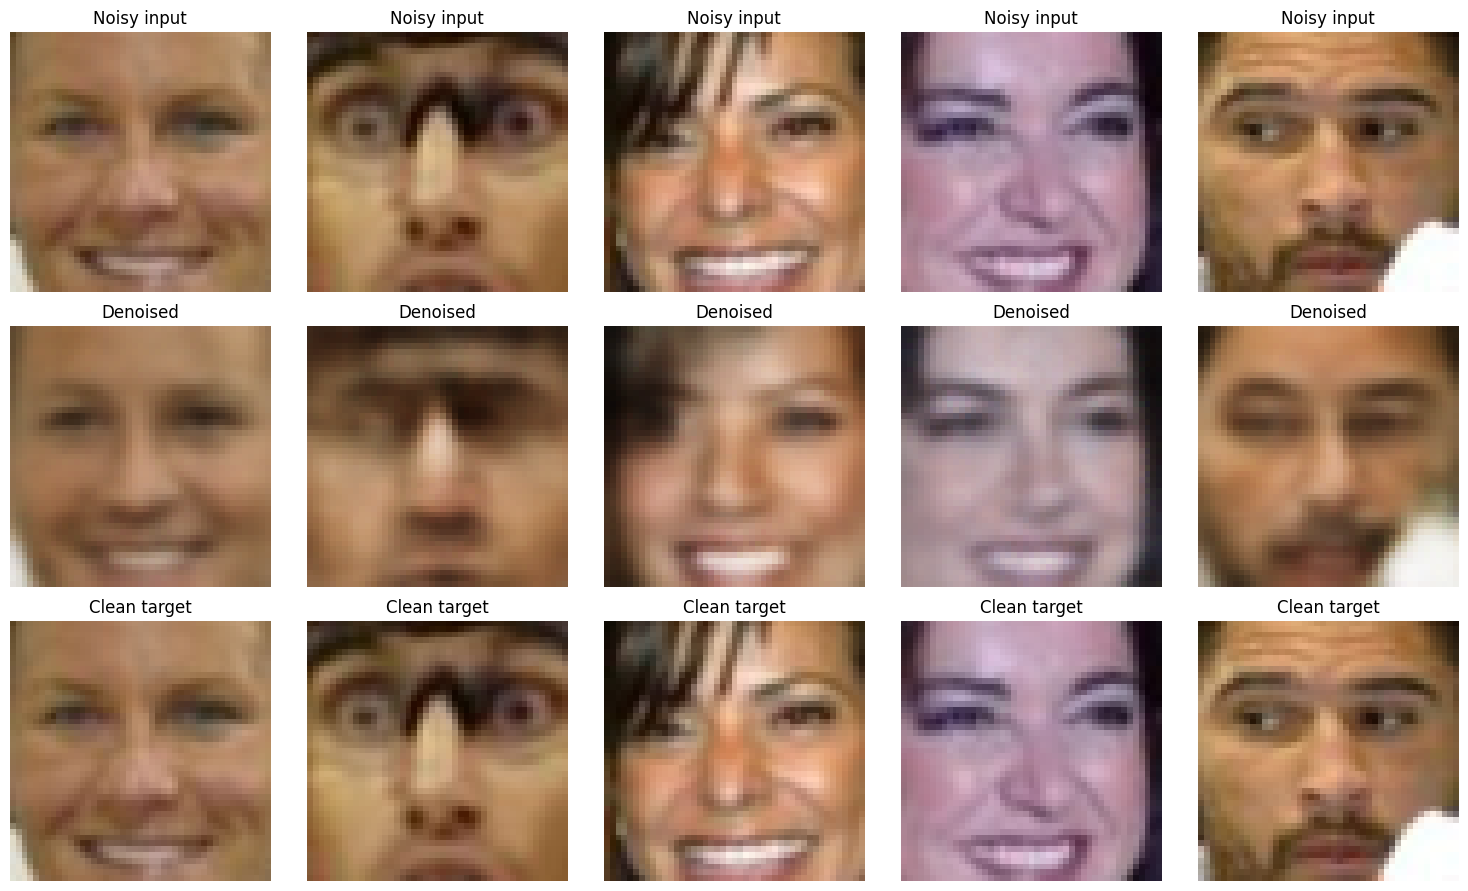

In [25]:
model.load_state_dict(torch.load("best_denoiser.pth"))
model.eval()

noisy_batch, clean_batch = next(iter(val_loader))
noisy_batch = noisy_batch.to(device)
with torch.no_grad():
    denoised_batch, _ = model(noisy_batch)

noisy_np = noisy_batch.cpu().permute(0,2,3,1).numpy()
clean_np = clean_batch.permute(0,2,3,1).numpy()
denoised_np = denoised_batch.cpu().permute(0,2,3,1).numpy()

num = 5
plt.figure(figsize=(15, 9))
for i in range(num):
    plt.subplot(3, num, i+1)
    plt.imshow(noisy_np[i])
    plt.title("Noisy input")
    plt.axis('off')

    plt.subplot(3, num, num + i+1)
    plt.imshow(denoised_np[i])
    plt.title("Denoised")
    plt.axis('off')

    plt.subplot(3, num, 2*num + i+1)
    plt.imshow(clean_np[i])
    plt.title("Clean target")
    plt.axis('off')
plt.tight_layout()
plt.show()

# BONUS 2: Image Retrieval (2 балла)



Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

Поскольку LSHForest удален из библиотеки склерн, будем использовать ближайших соседей.

Train codes shape: (10514, 128)
NearestNeighbors обучен


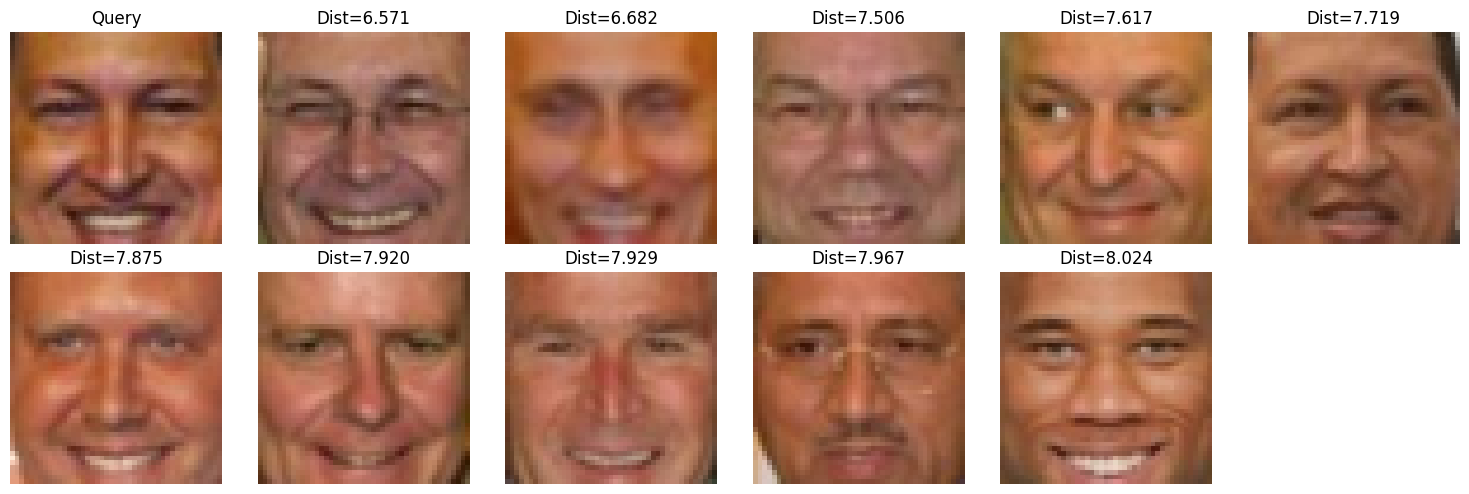

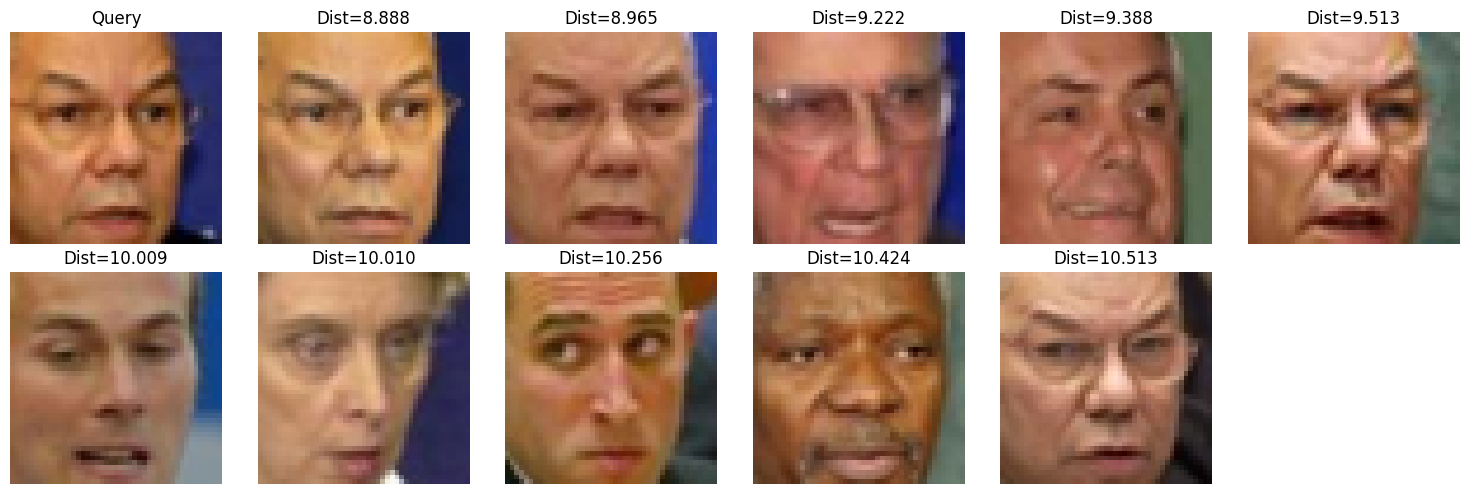

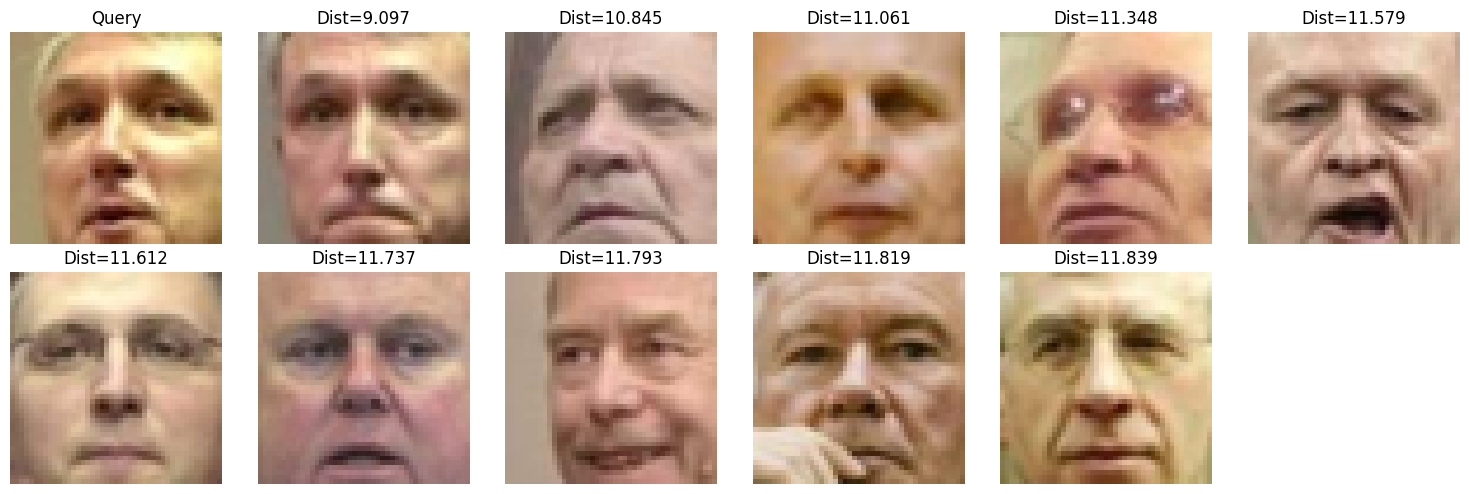

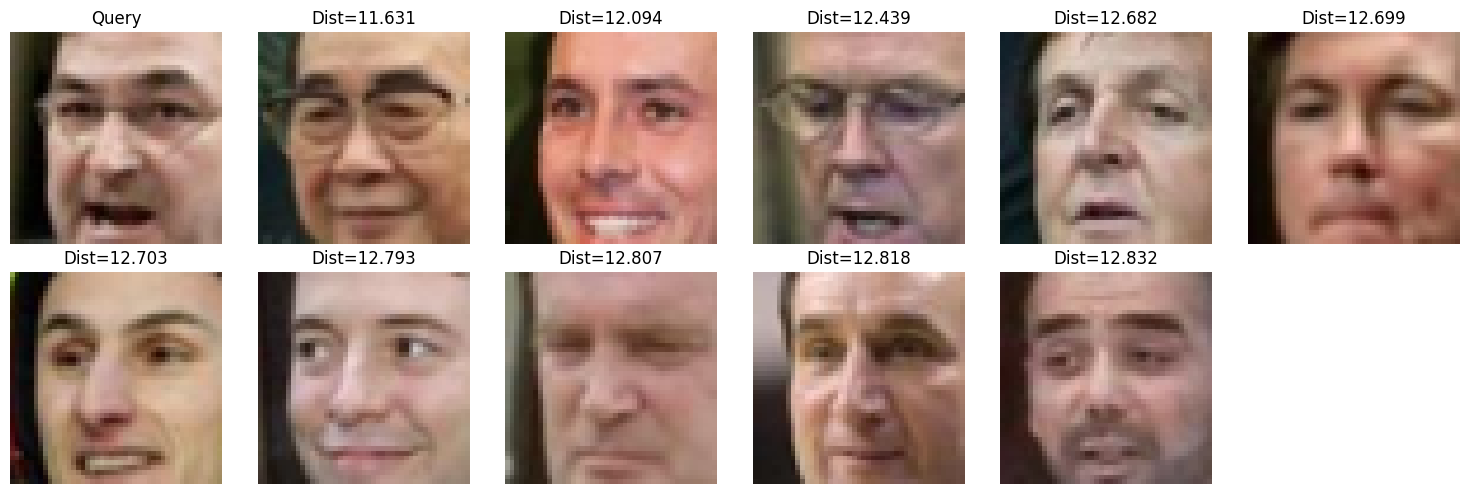

In [28]:
from sklearn.neighbors import NearestNeighbors

model.eval()
train_codes = []
batch_size = 128
with torch.no_grad():
    for i in range(0, len(train_clean_t), batch_size):
        batch = train_clean_t[i:i+batch_size].to(device)
        _, codes = model(batch)
        train_codes.append(codes.cpu().numpy())
train_codes = np.concatenate(train_codes, axis=0)

nn = NearestNeighbors(n_neighbors=11, algorithm='auto', metric='euclidean')
nn.fit(train_codes)

def get_similar(image_tensor, n_neighbors=5):
    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)
    image_tensor = image_tensor.to(device)
    with torch.no_grad():
        _, code = model(image_tensor)
    code_np = code.cpu().numpy().reshape(1, -1)
    distances, indices = nn.kneighbors(code_np, n_neighbors=n_neighbors)
    return distances[0], indices[0]

def show_similar(image_tensor, n_neighbors=11):
    distances, idx = get_similar(image_tensor, n_neighbors=n_neighbors)
    neighbors = train_clean_t[idx]
    orig_img = image_tensor.cpu().permute(1,2,0).numpy()
    plt.figure(figsize=(15, 5))
    plt.subplot(2, 6, 1)
    plt.imshow(orig_img)
    plt.title("Query")
    plt.axis('off')
    for i in range(n_neighbors):
        plt.subplot(2, 6, i+2)
        neighbor_img = neighbors[i].permute(1,2,0).numpy()
        plt.imshow(neighbor_img)
        plt.title(f"Dist={distances[i]:.3f}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

test_indices = np.random.choice(len(val_clean_t), 4, replace=False)
for idx in test_indices:
    test_img = val_clean_t[idx]
    show_similar(test_img, n_neighbors=10)

In [ ]:
<тут выведите самые похожие лица к какому-нибудь лицу из тестовой части датасета>